# Networks Assignment

## Libraries

In [54]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random

from sklearn.base import clone
from matplotlib.patches import Patch
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from networkx.algorithms.community import greedy_modularity_communities
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (RandomForestClassifier, VotingClassifier,
                              StackingClassifier, GradientBoostingClassifier)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import

In [55]:
# Import the edgelist document
raw_network = nx.read_edgelist('input_data/edges_train.edgelist', data=False, nodetype = int, delimiter=',')

In [56]:
# Create graph
G = raw_network.copy()

In [57]:
# Import the attributes csv
raw_attributes = pd.read_csv('input_data/attributes.csv')
raw_attributes.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         1800 non-null   int64
 1   attribute  1800 non-null   str  
dtypes: int64(1), str(1)
memory usage: 28.3 KB


In [58]:
attrs = raw_attributes.copy()

# Attach the attribute to every node now, so the per-group statistics below work
G.add_nodes_from(attrs.ID)
nx.set_node_attributes(G, dict(zip(attrs.ID, attrs.attribute)), 'attr')

## Functions

In [59]:
# Create the dictionary of communities based on greedy modularity
def community_map(graph, resolution):
    return {n: i for i, c in enumerate(greedy_modularity_communities(graph, resolution=resolution))
            for n in c}

In [60]:
# Draw a graph network
def draw_network(G, pos, node_colors=None, node_size=10, figsize=(8, 8)):
    """Thin transparent edges + nodes (optionally coloured). Returns nothing; call plt.show() after extras."""
    plt.figure(figsize=figsize)
    nx.draw_networkx_edges(G, pos, width=0.2, alpha=0.3)
    if node_colors is None:
        nx.draw_networkx_nodes(G, pos, node_size=node_size)
    else:
        nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_colors)

In [61]:
# Create a vector of features for each edge u-v of the graph
def features(Gf, u, v, comm_of):
    du, dv = Gf.degree(u), Gf.degree(v)
    return {
        "common_nb":   len(list(nx.common_neighbors(Gf, u, v))),
        "jaccard":     next(nx.jaccard_coefficient(Gf, [(u, v)]))[2],
        "adamic_adar": next(nx.adamic_adar_index(Gf, [(u, v)]))[2],
        "pref_attach": Gf.degree(u) * Gf.degree(v),
        "same_attr":   int(Gf.nodes[u]["attr"] == Gf.nodes[v]["attr"]),
        "same_comm":   int(comm_of[u] == comm_of[v]),
        # "max_deg":       max(du, dv),
    }

In [62]:
# One row of features
def feature_matrix(Gf, pairs, comm_of):
    return pd.DataFrame([features(Gf, u, v, comm_of) for u, v in pairs])

In [63]:
# Cross validation of the model on the training data, returning scores
def evaluate_model(name, model, X_train, y_train, X_test=None, y_test=None, cv=5):
    scores = cross_val_score(model, X_train, y_train, cv=cv)
    line = f"{name}: CV {scores.mean():.3f} ± {scores.std():.3f}"
    test_acc = None
    if X_test is not None:
        model.fit(X_train, y_train)
        test_acc = model.score(X_test, y_test)
        line += f" | Test {test_acc:.3f}"
    print(line)
    return {"cv_mean": scores.mean(), "cv_std": scores.std(), "test_acc": test_acc}

In [64]:
# Get the best parameters for a fitted gridsearch
def search_summary(search, X_test, y_test):
    return {
        "best_params": search.best_params_,
        "cv_mean": search.best_score_,
        "cv_std": search.cv_results_["std_test_score"][search.best_index_],
        "test_acc": search.score(X_test, y_test),
    }

## Analysis
### Network

In [65]:
# Nodes, edges, density and isolates
N = G.number_of_nodes()
E = G.number_of_edges()

print(f'Nodes: {N}')
print(f'Edges: {E}')
print(f'Density: {nx.density(G)}')
print(f'# of isolates: {nx.number_of_isolates(G)}')

Nodes: 1800
Edges: 6377
Density: 0.003938607868568958
# of isolates: 0


In [66]:
# Connected components
lcc = G.subgraph(max(nx.connected_components(G), key=len))
print(nx.number_connected_components(G), lcc.number_of_nodes())

1 1800


In [67]:
# Degree distribution
deg = pd.Series(dict(G.degree()))
print('Degree distribution')
print(deg.describe())

Degree distribution
count    1800.000000
mean        7.085556
std         6.852403
min         1.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        62.000000
dtype: float64


In [68]:
# Degree mean grouped by attribute
attr_s = pd.Series(nx.get_node_attributes(G, 'attr'))
print('Degree mean distribution')
print(deg.groupby(attr_s).mean())

Degree mean distribution
a    6.776667
b    7.116667
c    7.413333
d    6.976667
e    7.283333
f    6.946667
dtype: float64


In [69]:
# Clustering
C = nx.average_clustering(G)
print(C)

0.10908775663792247


### Attributes

In [70]:
pos = nx.spring_layout(G, seed=42)

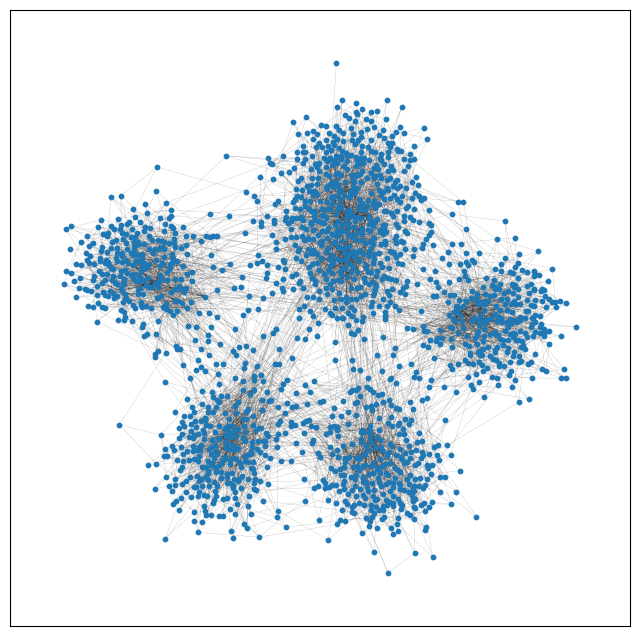

In [71]:
# Draw the original graph
draw_network(G, pos, node_size=10)
plt.show()

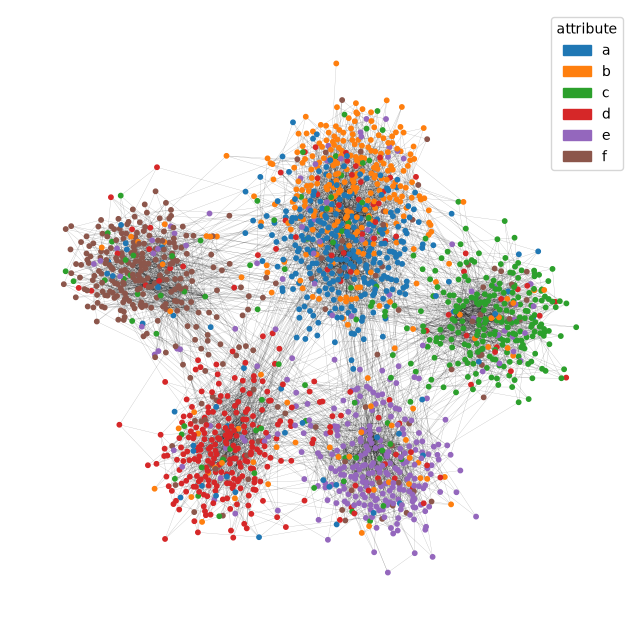

In [72]:
# Draw the graph coloured by attribute
cats = sorted(attrs.attribute.unique())
cmap = plt.get_cmap('tab10')
color_of = {c: cmap(i) for i, c in enumerate(cats)}
node_colors = [color_of[G.nodes[n]['attr']] for n in G.nodes()]

draw_network(G, pos, node_colors=node_colors, node_size=10)
plt.legend(handles=[Patch(color=color_of[c], label=c) for c in cats], title='attribute')
plt.axis('off'); plt.show()

6 communities


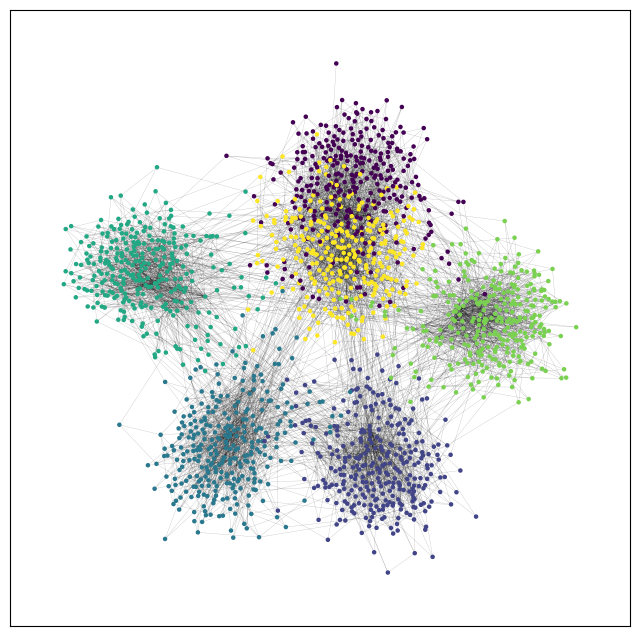

In [73]:
# Use modularity communities to segment the network
community_of = community_map(G, resolution=0.8)
print(len(set(community_of.values())), 'communities')

node_colors = [community_of[node] for node in G.nodes()]
draw_network(G, pos, node_colors=node_colors, node_size=5)
plt.show()

## Link prediction

## Features

In [74]:
# Remove 10% of the dataset
random.seed(42)

edges = list(G.edges())
nodes = list(G.nodes())

n_hide = int(0.1 * len(edges))
hidden = random.sample(edges, n_hide)

G_feat = G.copy()
G_feat.remove_edges_from(hidden)

neg = set()

In [75]:
# Create the negative edges
while len(neg) < n_hide:
    u, v = random.sample(nodes, 2)
    if not G.has_edge(u, v):
        neg.add((min(u, v), max(u, v)))

In [76]:
# Communities computed on G_feat (not on G) → no leakage
RESOLUTION = 1.5
comm_of = community_map(G_feat, resolution=RESOLUTION)

pairs  = hidden + list(neg)
Y      = np.array([1]*len(hidden) + [0]*len(neg))
X      = feature_matrix(G_feat, pairs, comm_of)

In [77]:
# See relevance of features
pd.Series({f: roc_auc_score(Y, X[f]) for f in X.columns}).sort_values(ascending=False)

same_comm      0.853218
pref_attach    0.683956
same_attr      0.678964
adamic_adar    0.672859
common_nb      0.672178
jaccard        0.669271
dtype: float64

In [78]:
# Search for best community parameter
for r in [0.5, 1.0, 1.5, 2.0, 3.0]:
    comm_r = community_map(G_feat, resolution=r)
    X_r = X.copy()
    X_r['same_comm'] = [int(comm_r[u] == comm_r[v]) for u, v in pairs]
    print(r, roc_auc_score(Y, X_r['same_comm']))

0.5 0.8414442700156985
1.0 0.8524332810047096
1.5 0.8532182103610676
2.0 0.8383045525902668
3.0 0.6805337519623235


In [79]:
# Split data, not using train-validation-test because later cross-validations is used
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=42)

### Models

In [80]:
# Model of Logistic regression
clf = LogisticRegression(random_state=0, C=2.0)
lr_scores = evaluate_model('Logistic regression', clf, X_train, y_train, X_test, y_test)

Logistic regression: CV 0.853 ± 0.027 | Test 0.867


In [81]:
# Model of Decision Tree Classifier
dtc = DecisionTreeClassifier(max_depth=2)
dt_scores = evaluate_model('Decision tree', dtc, X_train, y_train, X_test, y_test)

Decision tree: CV 0.847 ± 0.030 | Test 0.871


In [82]:
# Comparison against a Random Forest
models = {
    'Decision tree': DecisionTreeClassifier(max_depth=2, random_state=42),
    'Random forest': RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
}

for name, model in models.items():
    evaluate_model(name, model, X_train, y_train, X_test, y_test)

# Which features does the forest rely on?
rf = models['Random forest']
print(pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).round(3))

Decision tree: CV 0.847 ± 0.030 | Test 0.871
Random forest: CV 0.855 ± 0.031 | Test 0.855
same_comm      0.532
pref_attach    0.155
jaccard        0.084
adamic_adar    0.084
same_attr      0.077
common_nb      0.069
dtype: float64


In [83]:
# Try different depths
for d in [2, 3, 5, 8, None]:
    dt = cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42), X_train, y_train, cv=5).mean()
    rf = cross_val_score(RandomForestClassifier(n_estimators=200, max_depth=d, random_state=42), X_train, y_train, cv=5).mean()
    print(f'depth={d}:  DT {dt:.3f} | RF {rf:.3f}')

depth=2:  DT 0.847 | RF 0.851
depth=3:  DT 0.847 | RF 0.851
depth=5:  DT 0.844 | RF 0.855
depth=8:  DT 0.830 | RF 0.837
depth=None:  DT 0.806 | RF 0.838


In [84]:
# Try different approaches to merge Decision Trees and Random Forest
dt = DecisionTreeClassifier(max_depth=2, random_state=42)
rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)

models = {
    'Voting (DT+RF)':   VotingClassifier([('dt', dt), ('rf', rf)], voting='soft'),
    'Stacking (DT+RF)': StackingClassifier([('dt', dt), ('rf', rf)],
                                           final_estimator=LogisticRegression()),
    'Boosting':         GradientBoostingClassifier(n_estimators=100, max_depth=2, random_state=42),
}

for name, model in models.items():
    evaluate_model(name, model, X_train, y_train)      # CV only

Voting (DT+RF): CV 0.849 ± 0.032
Stacking (DT+RF): CV 0.849 ± 0.032
Boosting: CV 0.843 ± 0.036


### Testing Hyperparameters

In [85]:
# Decision tree
dt_grid = {
    'max_depth': [1, 2, 3, 4, 5, 8, None],
    'min_samples_leaf': [1, 5, 20, 50],
    'criterion': ['gini', 'entropy'],
}
dt_search = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_grid, cv=5, scoring='accuracy')
dt_search.fit(X_train, y_train)

# Logistic regression (scaler inside the pipeline)
lr_pipe = make_pipeline(StandardScaler(), LogisticRegression(solver='saga', max_iter=5000))
lr_grid = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logisticregression__l1_ratio': [0, 0.5, 1],     # L2, elastic net, L1
}
lr_search = GridSearchCV(lr_pipe, lr_grid, cv=5, scoring='accuracy')
lr_search.fit(X_train, y_train)

for name, s in [('Decision tree', dt_search), ('Logistic regression', lr_search)]:
    summary = search_summary(s, X_test, y_test)
    print(f'{name}: {summary['best_params']}')
    print(f'   CV {summary['cv_mean']:.3f} ± {summary['cv_std']:.3f} | Test {summary['test_acc']:.3f}')

Decision tree: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1}
   CV 0.849 ± 0.032 | Test 0.871
Logistic regression: {'logisticregression__C': 0.1, 'logisticregression__l1_ratio': 0}
   CV 0.853 ± 0.027 | Test 0.871


## Kaggle

In [86]:
# Declare final model
chosen_search = dt_search
chosen_name   = 'Decision tree'

# chosen_search = lr_search
# chosen_name   = 'Logistic regresion'

summary = search_summary(chosen_search, X_test, y_test)

print('=' * 60)
print(f'FINAL MODEL: {chosen_name}')
for k, v in summary['best_params'].items():
    print(f'   {k:20s} = {v}')
print(f'   CV accuracy (train) = {summary['cv_mean']:.3f} ± {summary['cv_std']:.3f}')
print(f'   Test accuracy       = {summary['test_acc']:.3f}')
print('=' * 60)

FINAL MODEL: Decision tree
   criterion            = entropy
   max_depth            = 3
   min_samples_leaf     = 1
   CV accuracy (train) = 0.849 ± 0.032
   Test accuracy       = 0.871


In [87]:
# Refit on the complete data with hyper parameteres
final_model = clone(chosen_search.best_estimator_)
final_model.fit(X, Y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

In [88]:
# Features for test file
solution = pd.read_csv('input_data/solutionInput.csv')
comm_G = community_map(G, resolution=RESOLUTION)

X_sol = feature_matrix(G, zip(solution.int1, solution.int2), comm_G)
X_sol = X_sol[X_train.columns]   

In [89]:
# Predict and save
solution['prediction'] = final_model.predict(X_sol)
print('Predicted positive rate:', round(solution.prediction.mean(), 3), '(should be ≈ 0.5)')
solution[['ID', 'prediction']].to_csv('output_kaggle/solution_output.csv', index=False)

Predicted positive rate: 0.552 (should be ≈ 0.5)


# Prediction interface

In [90]:
# Prediction for a single edge given as input
u, v = 164, 1010
x = feature_matrix(G, [(u, v)], comm_G)[X_train.columns]
print(f'Link {u}-{v}:', final_model.predict(x)[0])

Link 164-1010: 1
